# Progressive Dataset Revelation for Deep Learning Training

This notebook investigates how different data exposure strategies affect model learning.  
We train **VGG-style CNN**, **ResNet-18**, and **EfficientNet-B0** under three strategies:

1. Full dataset training (baseline)
2. Progressive revelation: 10% → 25% → 50% → 75% → 100%
3. Curriculum learning: easy samples first, hard samples later

**Dataset:** CIFAR-10 and CIFAR-100 (https://www.cs.toronto.edu/~kriz/cifar.html)  
**Unique additions:** Catastrophic forgetting tracking, efficiency metrics (accuracy/GPU-hour), and a hybrid Strategy 4.

## 1. Setup & Imports

In [1]:

!pip install wandb --quiet

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
import numpy as np
import time
import json
import wandb
import matplotlib.pyplot as plt
from collections import defaultdict

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using: {DEVICE}')

Using: cuda


## 2. Configuration

All hyperparameters and experiment settings.

In [ ]:
CFG = {
    'batch_size': 128,
    'epochs_per_stage': 20,      # epochs at each data stage
    'lr': 0.1,
    'momentum': 0.9,
    'weight_decay': 5e-4,
    'stages': [0.10, 0.25, 0.50, 0.75, 1.00],  # progressive revelation percentages
    'seed': 42,
    'use_wandb': False,
    'save_dir': './checkpoints'
}

import os
os.makedirs(CFG['save_dir'], exist_ok=True)

torch.manual_seed(CFG['seed'])
np.random.seed(CFG['seed'])

## 3. Dataset Loading

We load both CIFAR-10 and CIFAR-100. Normalization values are dataset-specific.  
CIFAR-10 has 10 classes, CIFAR-100 has 100 — lets us compare how strategies scale with complexity.

In [ ]:
# Standard augmentation for training — nothing fancy, just what works
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

# CIFAR-100 has different normalization stats
train_transform_100 = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
])

val_transform_100 = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
])

# Download CIFAR-10
cifar10_train = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=train_transform)
cifar10_val   = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=val_transform)

# Download CIFAR-100
cifar100_train = torchvision.datasets.CIFAR100(root='./data', train=True,  download=True, transform=train_transform_100)
cifar100_val   = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=val_transform_100)

print(f'CIFAR-10  — Train: {len(cifar10_train)}, Val: {len(cifar10_val)}')
print(f'CIFAR-100 — Train: {len(cifar100_train)}, Val: {len(cifar100_val)}')

100%|██████████| 170M/170M [00:01<00:00, 101MB/s]  
100%|██████████| 169M/169M [00:02<00:00, 80.0MB/s] 


CIFAR-10  — Train: 50000, Val: 10000
CIFAR-100 — Train: 50000, Val: 10000


### 3.1 Visualize a batch



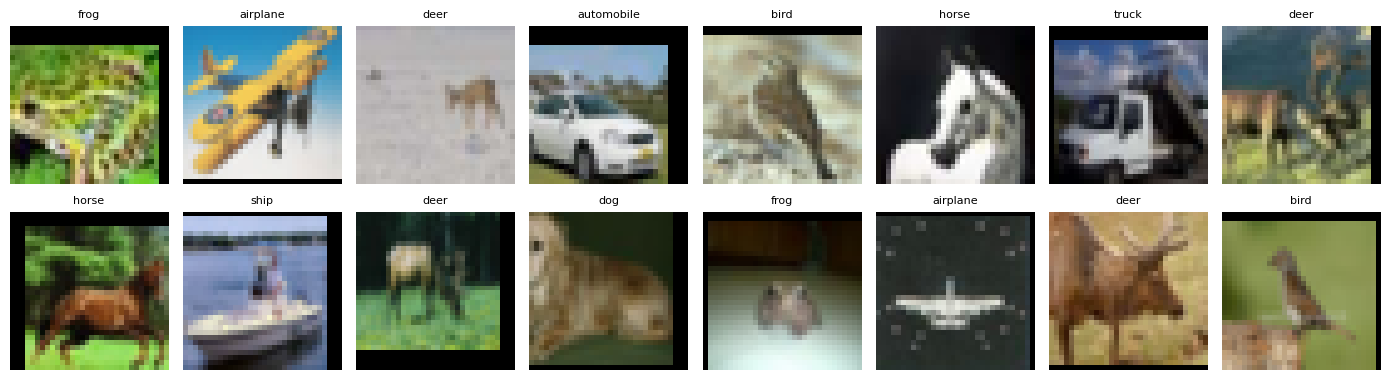

In [ ]:
CIFAR10_CLASSES = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

def show_batch(dataset, classes, n=16):
    loader = DataLoader(dataset, batch_size=n, shuffle=True)
    images, labels = next(iter(loader))

    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3,1,1)
    std  = torch.tensor([0.2023, 0.1994, 0.2010]).view(3,1,1)
    images = images * std + mean
    images = images.clamp(0, 1)

    fig, axes = plt.subplots(2, n//2, figsize=(14, 4))
    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i].permute(1, 2, 0))
        ax.set_title(classes[labels[i]], fontsize=8)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_batch(cifar10_train, CIFAR10_CLASSES)

## 4. Data Subset Utilities

Helper functions to create subsets for progressive revelation. We also need a function to score samples by difficulty — we'll use prediction entropy from a quick warm-up training run.

In [ ]:
def get_random_subset(dataset, fraction, seed=42):
    n = int(len(dataset) * fraction)
    rng = np.random.default_rng(seed)
    indices = rng.choice(len(dataset), n, replace=False)
    return Subset(dataset, indices), indices


def score_difficulty(model, dataset, batch_size=256):
    """Assign each sample an entropy score. High entropy = model is confused = hard sample."""
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    entropy_scores = []

    with torch.no_grad():
        for images, _ in loader:
            images = images.to(DEVICE)
            logits = model(images)
            probs = torch.softmax(logits, dim=1)
            entropy = -(probs * torch.log(probs + 1e-8)).sum(dim=1)
            entropy_scores.extend(entropy.cpu().numpy())

    return np.array(entropy_scores)


def get_curriculum_subsets(dataset, difficulty_scores, stages):
    """
    Sort by difficulty (ascending = easy first).
    At each stage, reveal the next chunk of harder samples.
    """
    sorted_indices = np.argsort(difficulty_scores)   # easy → hard
    subsets = []
    for frac in stages:
        n = int(len(dataset) * frac)
        subsets.append(Subset(dataset, sorted_indices[:n]))
    return subsets


def make_loader(subset, batch_size, shuffle=True):
    return DataLoader(subset, batch_size=batch_size, shuffle=shuffle,
                      num_workers=2, pin_memory=True)

## 5. Model Architectures


In [ ]:
# ── VGG-style CNN ──────────────────────────────────────────────────────────────
class VGGStyle(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # 16x16
            # Block 2
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # 8x8
            # Block 3
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # 4x4
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 4 * 4, 512), nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

In [ ]:
# ── ResNet-18 ──────────────────────────────────────────────────────────────────
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.relu  = nn.ReLU(inplace=True)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)   # the skip connection
        return self.relu(out)


class ResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.prep = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True)
        )
        self.layer1 = self._make_layer(64,  64,  stride=1)
        self.layer2 = self._make_layer(64,  128, stride=2)
        self.layer3 = self._make_layer(128, 256, stride=2)
        self.layer4 = self._make_layer(256, 512, stride=2)
        self.pool   = nn.AdaptiveAvgPool2d(1)
        self.fc     = nn.Linear(512, num_classes)

    def _make_layer(self, in_ch, out_ch, stride):
        return nn.Sequential(
            ResBlock(in_ch, out_ch, stride),
            ResBlock(out_ch, out_ch, 1)
        )

    def forward(self, x):
        x = self.prep(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.pool(x).view(x.size(0), -1)
        return self.fc(x)

In [ ]:
# ── EfficientNet-B0 ────────────────────────────────────────────────────────────
from torchvision.models import efficientnet_b0

def get_efficientnet(num_classes=10):
    model = efficientnet_b0(weights=None)  # training from scratch
    # replace the classifier head for our number of classes
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model


def get_model(name, num_classes=10):
    models = {
        'vgg':         VGGStyle(num_classes),
        'resnet':      ResNet18(num_classes),
        'efficientnet': get_efficientnet(num_classes)
    }
    return models[name].to(DEVICE)


# Quick parameter count sanity check
for name in ['vgg', 'resnet', 'efficientnet']:
    m = get_model(name)
    params = sum(p.numel() for p in m.parameters()) / 1e6
    print(f'{name:15s} → {params:.2f}M parameters')

vgg             → 3.25M parameters
resnet          → 11.17M parameters
efficientnet    → 4.02M parameters


## 6. Training & Evaluation Functions

One epoch of training and one pass of evaluation. Nothing fancy
SGD with cosine annealing because it consistently works well on CIFAR.

In [ ]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct += outputs.argmax(1).eq(labels).sum().item()
        total += images.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader):
    model.eval()
    correct, total, total_loss = 0, 0, 0
    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            correct += outputs.argmax(1).eq(labels).sum().item()
            total += images.size(0)

    return total_loss / total, correct / total

## 7. Results Logger

All results go into a dict that we dump to JSON at the end. This JSON feeds the web dashboard.

In [ ]:
RESULTS_FILE = 'results.json'

def load_existing_results():
    if os.path.exists(RESULTS_FILE):
        with open(RESULTS_FILE) as f:
            existing = json.load(f)
        print(f'Loaded {len(existing)} existing results from {RESULTS_FILE}')
        return defaultdict(dict, existing)
    print('Starting fresh — no existing results.json')
    return defaultdict(dict)

results_store = load_existing_results()

def log_result(model_name, strategy, dataset_name, metrics):
    key = f'{model_name}_{strategy}_{dataset_name}'
    results_store[key] = metrics
    with open(RESULTS_FILE, 'w') as f:
        json.dump(dict(results_store), f, indent=2)
    print(f'  ✓ saved [{key}]  acc={metrics["final_val_acc"]:.3f}  time={metrics["gpu_hours"]:.3f}h')

def save_results():
    with open(RESULTS_FILE, 'w') as f:
        json.dump(dict(results_store), f, indent=2)
    print(f'Saved {len(results_store)} results to {RESULTS_FILE}')

Starting fresh — no existing results.json


## 8. Strategy Implementations

### Strategy 1 — Full Dataset Baseline

In [ ]:
def run_strategy1_full(model_name, train_dataset, val_dataset, dataset_name, num_classes):
    print(f'\n=== Strategy 1 | {model_name} | {dataset_name} ===')

    model     = get_model(model_name, num_classes)
    optimizer = optim.SGD(model.parameters(), lr=CFG['lr'],
                          momentum=CFG['momentum'], weight_decay=CFG['weight_decay'])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG['epochs_per_stage'])
    criterion = nn.CrossEntropyLoss()

    train_loader = make_loader(train_dataset, CFG['batch_size'])
    val_loader   = make_loader(val_dataset,   CFG['batch_size'], shuffle=False)

    history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}
    t_start = time.time()

    for epoch in range(CFG['epochs_per_stage']):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
        vl_loss, vl_acc = evaluate(model, val_loader)
        scheduler.step()

        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)

        if (epoch + 1) % 5 == 0:
            print(f'  Epoch {epoch+1:3d} | train_acc={tr_acc:.3f} | val_acc={vl_acc:.3f}')

    gpu_hours = (time.time() - t_start) / 3600
    metrics = {
        'strategy': 'full_dataset',
        'history': history,
        'final_val_acc': history['val_acc'][-1],
        'best_val_acc':  max(history['val_acc']),
        'gpu_hours': gpu_hours,
        'acc_per_gpu_hour': history['val_acc'][-1] / max(gpu_hours, 1e-6)
    }
    log_result(model_name, 'strategy1_full', dataset_name, metrics)
    return model, metrics

### Strategy 2 — Progressive Dataset Revelation

In [ ]:
def run_strategy2_progressive(model_name, train_dataset, val_dataset, dataset_name, num_classes):
    print(f'\n=== Strategy 2 | {model_name} | {dataset_name} ===')

    model     = get_model(model_name, num_classes)
    criterion = nn.CrossEntropyLoss()
    val_loader = make_loader(val_dataset, CFG['batch_size'], shuffle=False)

    history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}
    forgetting_log = []   # unique: track accuracy on previous stage's data
    prev_subset = None
    t_start = time.time()

    for stage_idx, frac in enumerate(CFG['stages']):
        print(f'  Stage {stage_idx+1}: {int(frac*100)}% data ({int(len(train_dataset)*frac)} samples)')

        current_subset, _ = get_random_subset(train_dataset, frac)
        train_loader      = make_loader(current_subset, CFG['batch_size'])

        # fresh LR warmup at each stage (pacing-aware scheduler)
        optimizer = optim.SGD(model.parameters(), lr=CFG['lr'],
                              momentum=CFG['momentum'], weight_decay=CFG['weight_decay'])
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG['epochs_per_stage'])

        for epoch in range(CFG['epochs_per_stage']):
            tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
            vl_loss, vl_acc = evaluate(model, val_loader)
            scheduler.step()

            history['train_acc'].append(tr_acc)
            history['val_acc'].append(vl_acc)
            history['train_loss'].append(tr_loss)
            history['val_loss'].append(vl_loss)

        if prev_subset is not None:
            prev_loader = make_loader(prev_subset, CFG['batch_size'], shuffle=False)
            _, prev_acc = evaluate(model, prev_loader)
            forgetting_log.append({'stage': stage_idx+1, 'prev_acc': prev_acc})
            print(f'  Forgetting check — acc on prev stage data: {prev_acc:.3f}')

        prev_subset = current_subset
        print(f'  End of stage — val_acc: {history["val_acc"][-1]:.3f}')

    gpu_hours = (time.time() - t_start) / 3600
    metrics = {
        'strategy': 'progressive',
        'history': history,
        'final_val_acc': history['val_acc'][-1],
        'best_val_acc':  max(history['val_acc']),
        'forgetting_log': forgetting_log,
        'gpu_hours': gpu_hours,
        'acc_per_gpu_hour': history['val_acc'][-1] / max(gpu_hours, 1e-6)
    }
    log_result(model_name, 'strategy2_progressive', dataset_name, metrics)
    return model, metrics

### Strategy 3 — Curriculum Learning (Easy → Hard)

In [ ]:
def warmup_for_difficulty_scoring(train_dataset, num_classes, warmup_epochs=5):
    """Train a small VGG for a few epochs just to get difficulty scores. Not saved."""
    print('  Running warm-up to compute difficulty scores...')
    probe = VGGStyle(num_classes).to(DEVICE)
    opt   = optim.SGD(probe.parameters(), lr=0.01, momentum=0.9)
    crit  = nn.CrossEntropyLoss()
    loader = make_loader(train_dataset, 256)

    for _ in range(warmup_epochs):
        train_epoch(probe, loader, opt, crit)

    scores = score_difficulty(probe, train_dataset)
    del probe
    return scores


def run_strategy3_curriculum(model_name, train_dataset, val_dataset, dataset_name, num_classes):
    print(f'\n=== Strategy 3 | {model_name} | {dataset_name} ===')

    # Step 1: score all samples by difficulty
    difficulty_scores = warmup_for_difficulty_scoring(train_dataset, num_classes)
    curriculum_subsets = get_curriculum_subsets(train_dataset, difficulty_scores, CFG['stages'])

    model     = get_model(model_name, num_classes)
    criterion = nn.CrossEntropyLoss()
    val_loader = make_loader(val_dataset, CFG['batch_size'], shuffle=False)

    history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}
    t_start = time.time()

    for stage_idx, subset in enumerate(curriculum_subsets):
        frac = CFG['stages'][stage_idx]
        print(f'  Stage {stage_idx+1}: easiest {int(frac*100)}% ({len(subset)} samples)')

        train_loader = make_loader(subset, CFG['batch_size'])
        optimizer    = optim.SGD(model.parameters(), lr=CFG['lr'],
                                 momentum=CFG['momentum'], weight_decay=CFG['weight_decay'])
        scheduler    = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG['epochs_per_stage'])

        for epoch in range(CFG['epochs_per_stage']):
            tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
            vl_loss, vl_acc = evaluate(model, val_loader)
            scheduler.step()

            history['train_acc'].append(tr_acc)
            history['val_acc'].append(vl_acc)
            history['train_loss'].append(tr_loss)
            history['val_loss'].append(vl_loss)

        print(f'  End of stage — val_acc: {history["val_acc"][-1]:.3f}')

    gpu_hours = (time.time() - t_start) / 3600
    metrics = {
        'strategy': 'curriculum',
        'history': history,
        'final_val_acc': history['val_acc'][-1],
        'best_val_acc':  max(history['val_acc']),
        'difficulty_scores': difficulty_scores.tolist(),
        'gpu_hours': gpu_hours,
        'acc_per_gpu_hour': history['val_acc'][-1] / max(gpu_hours, 1e-6)
    }
    log_result(model_name, 'strategy3_curriculum', dataset_name, metrics)
    return model, metrics

### Strategy 4 — Hybrid (Progressive + Curriculum) — *Original Contribution*

Within each data stage, instead of random sampling, we pick the easiest samples available. As stages grow, we gradually include harder ones.

In [ ]:
def run_strategy4_hybrid(model_name, train_dataset, val_dataset, dataset_name, num_classes):
    print(f'\n=== Strategy 4 (Hybrid) | {model_name} | {dataset_name} ===')

    difficulty_scores = warmup_for_difficulty_scoring(train_dataset, num_classes)
    sorted_indices    = np.argsort(difficulty_scores)  # easy → hard

    model     = get_model(model_name, num_classes)
    criterion = nn.CrossEntropyLoss()
    val_loader = make_loader(val_dataset, CFG['batch_size'], shuffle=False)

    history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}
    t_start = time.time()

    for stage_idx, frac in enumerate(CFG['stages']):
        n = int(len(train_dataset) * frac)
        # take the easiest n% of ALL data (expands with each stage)
        stage_indices = sorted_indices[:n]
        subset        = Subset(train_dataset, stage_indices)
        train_loader  = make_loader(subset, CFG['batch_size'])

        print(f'  Stage {stage_idx+1}: easiest {int(frac*100)}% = {n} samples')

        optimizer = optim.SGD(model.parameters(), lr=CFG['lr'],
                              momentum=CFG['momentum'], weight_decay=CFG['weight_decay'])
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG['epochs_per_stage'])

        for epoch in range(CFG['epochs_per_stage']):
            tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
            vl_loss, vl_acc = evaluate(model, val_loader)
            scheduler.step()

            history['train_acc'].append(tr_acc)
            history['val_acc'].append(vl_acc)
            history['train_loss'].append(tr_loss)
            history['val_loss'].append(vl_loss)

        print(f'  End of stage — val_acc: {history["val_acc"][-1]:.3f}')

    gpu_hours = (time.time() - t_start) / 3600
    metrics = {
        'strategy': 'hybrid',
        'history': history,
        'final_val_acc': history['val_acc'][-1],
        'best_val_acc':  max(history['val_acc']),
        'gpu_hours': gpu_hours,
        'acc_per_gpu_hour': history['val_acc'][-1] / max(gpu_hours, 1e-6)
    }
    log_result(model_name, 'strategy4_hybrid', dataset_name, metrics)
    return model, metrics

## 9. Run All Experiments

This is the main training loop.

In [ ]:
# Comment out what you don't want to run yet
results_store = load_existing_results()
MODELS   = ['vgg', 'resnet', 'efficientnet']
DATASETS = [
    ('cifar10',  cifar10_train,  cifar10_val,  10),
    ('cifar100', cifar100_train, cifar100_val, 100),
]

for ds_name, tr_ds, vl_ds, n_cls in DATASETS:
        run_strategy1_full('vgg', tr_ds, vl_ds, ds_name, n_cls)
        run_strategy2_progressive('vgg', tr_ds, vl_ds, ds_name, n_cls)
        run_strategy3_curriculum('vgg', tr_ds, vl_ds, ds_name, n_cls)
        run_strategy4_hybrid('vgg', tr_ds, vl_ds, ds_name, n_cls)

print('done ')

Starting fresh — no existing results.json

=== Strategy 1 | vgg | cifar10 ===
  Epoch   5 | train_acc=0.662 | val_acc=0.658
  Epoch  10 | train_acc=0.801 | val_acc=0.761
  Epoch  15 | train_acc=0.880 | val_acc=0.856
  Epoch  20 | train_acc=0.930 | val_acc=0.902
  ✓ saved [vgg_strategy1_full_cifar10]  acc=0.902  time=0.075h

=== Strategy 2 | vgg | cifar10 ===
  Stage 1: 10% data (5000 samples)
  End of stage — val_acc: 0.345
  Stage 2: 25% data (12500 samples)
  Forgetting check — acc on prev stage data: 0.820
  End of stage — val_acc: 0.767
  Stage 3: 50% data (25000 samples)
  Forgetting check — acc on prev stage data: 0.945
  End of stage — val_acc: 0.878
  Stage 4: 75% data (37500 samples)
  Forgetting check — acc on prev stage data: 0.969
  End of stage — val_acc: 0.907
  Stage 5: 100% data (50000 samples)
  Forgetting check — acc on prev stage data: 0.974
  End of stage — val_acc: 0.923
  ✓ saved [vgg_strategy2_progressive_cifar10]  acc=0.923  time=0.221h

=== Strategy 3 | vgg | c

In [ ]:
results_store = load_existing_results()

DATASETS = [
    ('cifar10',  cifar10_train,  cifar10_val,  10),
    ('cifar100', cifar100_train, cifar100_val, 100),
]

for ds_name, tr_ds, vl_ds, n_cls in DATASETS:
        run_strategy1_full('resnet', tr_ds, vl_ds, ds_name, n_cls)
        run_strategy2_progressive('resnet', tr_ds, vl_ds, ds_name, n_cls)
        run_strategy3_curriculum('resnet', tr_ds, vl_ds, ds_name, n_cls)
        run_strategy4_hybrid('resnet', tr_ds, vl_ds, ds_name, n_cls)

save_results()

Loaded 8 existing results from results.json

=== Strategy 1 | resnet | cifar10 ===
  Epoch   5 | train_acc=0.722 | val_acc=0.735
  Epoch  10 | train_acc=0.851 | val_acc=0.832
  Epoch  15 | train_acc=0.923 | val_acc=0.885
  Epoch  20 | train_acc=0.975 | val_acc=0.924
  ✓ saved [resnet_strategy1_full_cifar10]  acc=0.924  time=0.248h

=== Strategy 2 | resnet | cifar10 ===
  Stage 1: 10% data (5000 samples)
  End of stage — val_acc: 0.366
  Stage 2: 25% data (12500 samples)
  Forgetting check — acc on prev stage data: 0.764
  End of stage — val_acc: 0.711
  Stage 3: 50% data (25000 samples)
  Forgetting check — acc on prev stage data: 0.965
  End of stage — val_acc: 0.882
  Stage 4: 75% data (37500 samples)
  Forgetting check — acc on prev stage data: 0.990
  End of stage — val_acc: 0.922
  Stage 5: 100% data (50000 samples)
  Forgetting check — acc on prev stage data: 0.993
  End of stage — val_acc: 0.939
  ✓ saved [resnet_strategy2_progressive_cifar10]  acc=0.939  time=0.685h

=== Strate

In [ ]:
results_store = load_existing_results()

for ds_name, tr_ds, vl_ds, n_cls in DATASETS:
        run_strategy1_full('efficientnet', tr_ds, vl_ds, ds_name, n_cls)
        run_strategy2_progressive('efficientnet', tr_ds, vl_ds, ds_name, n_cls)
        run_strategy3_curriculum('efficientnet', tr_ds, vl_ds, ds_name, n_cls)
        run_strategy4_hybrid('efficientnet', tr_ds, vl_ds, ds_name, n_cls)

save_results()

Loaded 16 existing results from results.json

=== Strategy 1 | efficientnet | cifar10 ===
  Epoch   5 | train_acc=0.432 | val_acc=0.474
  Epoch  10 | train_acc=0.600 | val_acc=0.622
  Epoch  15 | train_acc=0.697 | val_acc=0.712
  Epoch  20 | train_acc=0.754 | val_acc=0.758
  ✓ saved [efficientnet_strategy1_full_cifar10]  acc=0.758  time=0.107h

=== Strategy 2 | efficientnet | cifar10 ===
  Stage 1: 10% data (5000 samples)
  End of stage — val_acc: 0.150
  Stage 2: 25% data (12500 samples)
  Forgetting check — acc on prev stage data: 0.297
  End of stage — val_acc: 0.326
  Stage 3: 50% data (25000 samples)
  Forgetting check — acc on prev stage data: 0.549
  End of stage — val_acc: 0.557
  Stage 4: 75% data (37500 samples)
  Forgetting check — acc on prev stage data: 0.721
  End of stage — val_acc: 0.724
  Stage 5: 100% data (50000 samples)
  Forgetting check — acc on prev stage data: 0.804
  End of stage — val_acc: 0.801
  ✓ saved [efficientnet_strategy2_progressive_cifar10]  acc=0.801

## 10. Visualization & Analysis

Plot learning curves for all experiments and the catastrophic forgetting analysis.

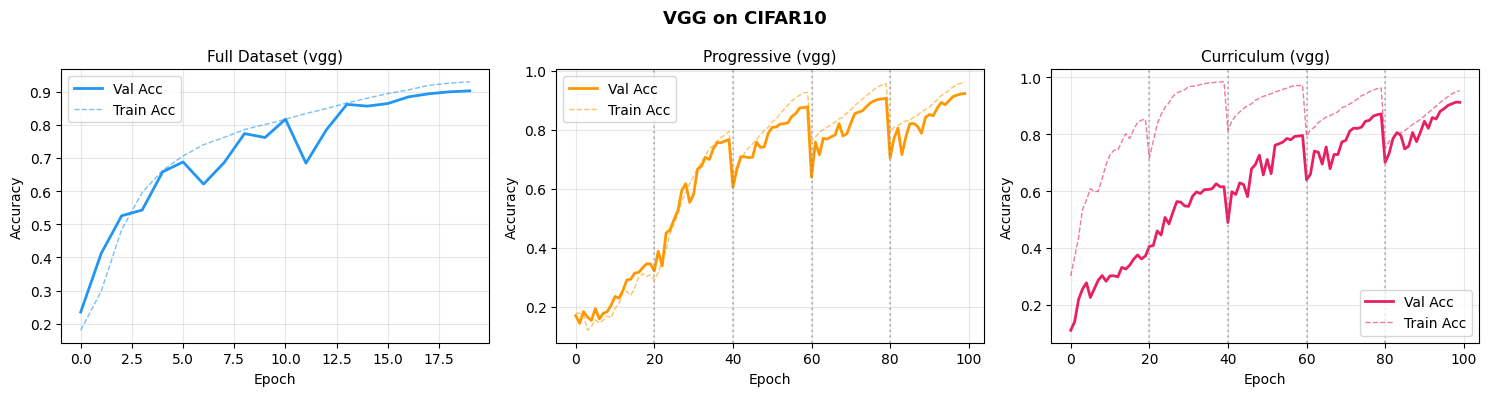

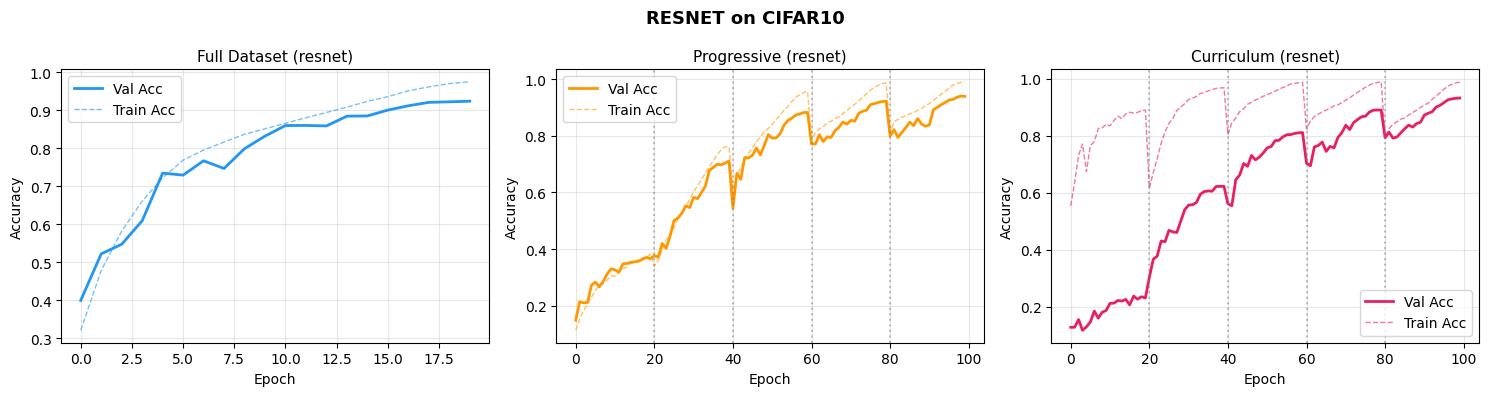

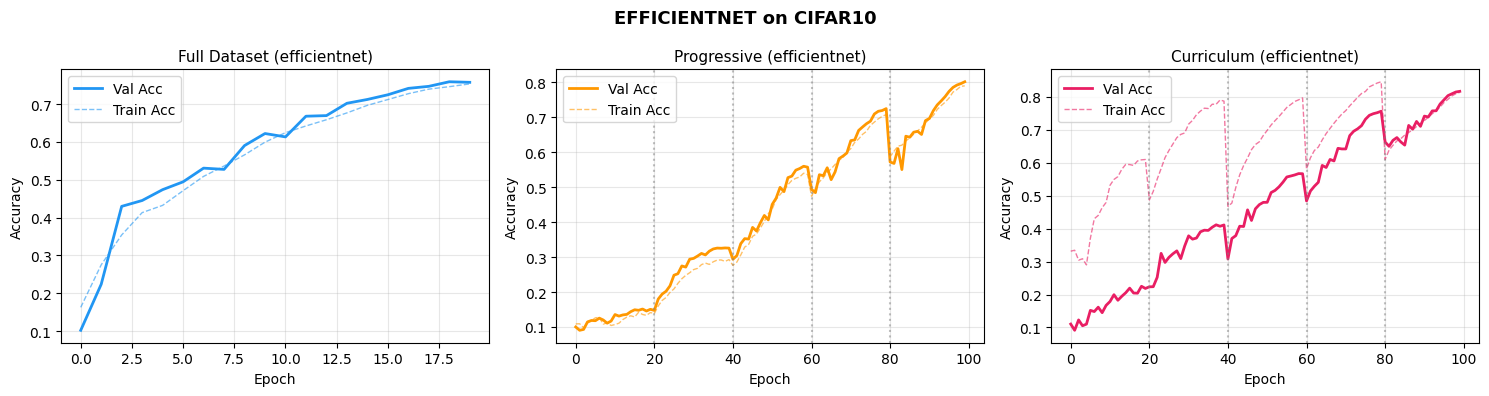

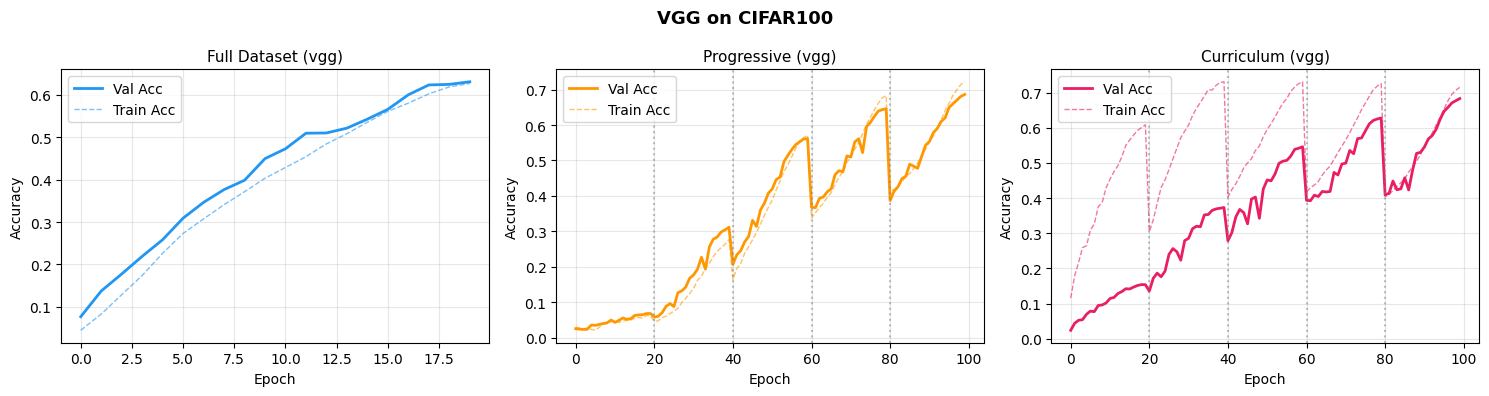

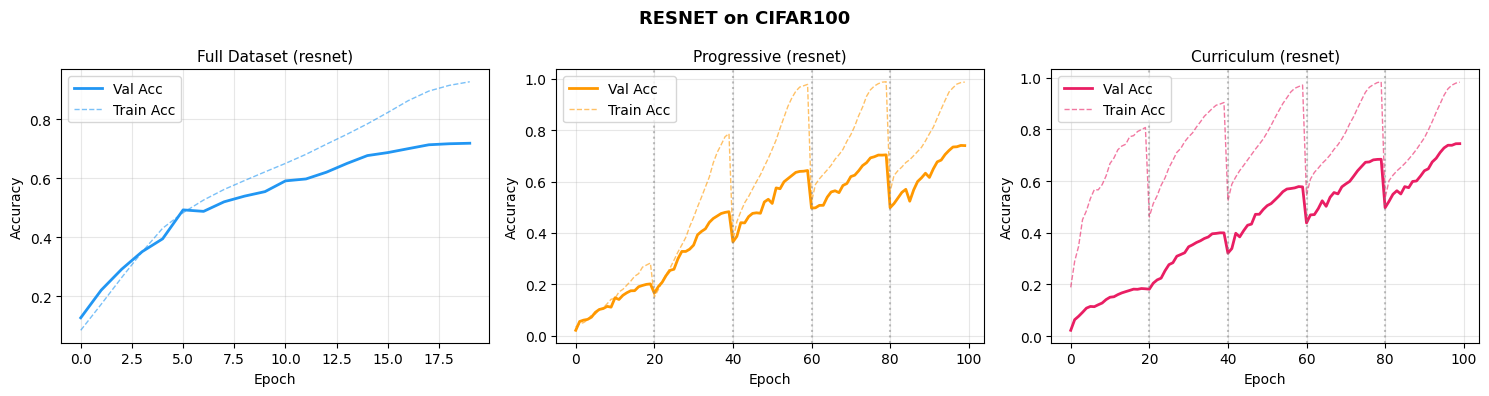

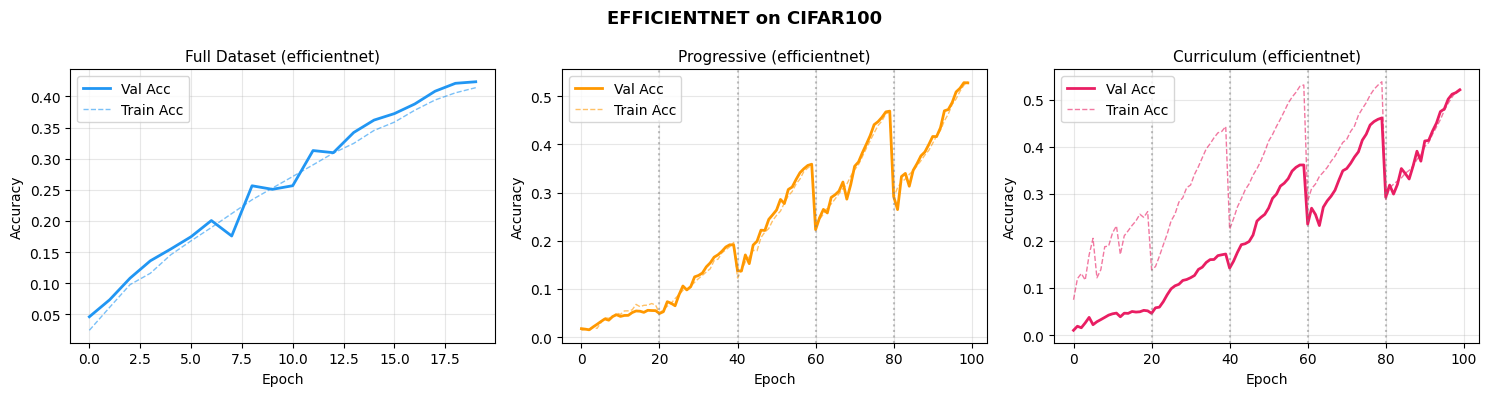

In [ ]:
def plot_learning_curves(results, model_name, dataset_name):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    strategies = ['strategy1_full', 'strategy2_progressive', 'strategy3_curriculum']
    labels     = ['Full Dataset', 'Progressive', 'Curriculum']
    colors     = ['#2196F3', '#FF9800', '#E91E63']

    for ax, strat, label, color in zip(axes, strategies, labels, colors):
        key = f'{model_name}_{strat}_{dataset_name}'
        if key not in results:
            ax.set_title(f'{label} (no data)')
            continue

        history = results[key]['history']
        ax.plot(history['val_acc'],   label='Val Acc',   color=color, linewidth=2)
        ax.plot(history['train_acc'], label='Train Acc', color=color, linewidth=1, linestyle='--', alpha=0.6)
        ax.set_title(f'{label} ({model_name})', fontsize=11)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Accuracy')
        ax.legend()
        ax.grid(alpha=0.3)

        # mark stage boundaries for progressive/curriculum
        if strat != 'strategy1_full':
            for i in range(1, len(CFG['stages'])):
                ax.axvline(i * CFG['epochs_per_stage'], color='gray', linestyle=':', alpha=0.5)

    plt.suptitle(f'{model_name.upper()} on {dataset_name.upper()}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'curves_{model_name}_{dataset_name}.png', dpi=120, bbox_inches='tight')
    plt.show()


with open('results.json') as f:
    results = json.load(f)

for ds_name, _, _, _ in DATASETS:
    for model_name in MODELS:
        plot_learning_curves(results, model_name, ds_name)

In [ ]:
# Final summary table — accuracy and efficiency
print(f'{'Model':<15} {'Strategy':<25} {'Dataset':<10} {'Val Acc':>8} {'GPU Hrs':>8} {'Acc/Hr':>8}')
print('-' * 80)

for key, metrics in sorted(results.items()):
    parts = key.split('_', 2)
    if len(parts) < 3:
        continue
    model_n  = parts[0]
    strategy = parts[1] + '_' + parts[2].rsplit('_', 1)[0]
    dataset  = key.split('_')[-1]

    acc  = metrics.get('final_val_acc', 0)
    hrs  = metrics.get('gpu_hours', 0)
    eff  = metrics.get('acc_per_gpu_hour', 0)
    print(f'{model_n:<15} {strategy:<25} {dataset:<10} {acc:>8.3f} {hrs:>8.3f} {eff:>8.2f}')

Model           Strategy                  Dataset     Val Acc  GPU Hrs   Acc/Hr
--------------------------------------------------------------------------------
efficientnet    strategy1_full            cifar10       0.758    0.107     7.06
efficientnet    strategy1_full            cifar100      0.423    0.106     3.99
efficientnet    strategy2_progressive     cifar10       0.801    0.312     2.57
efficientnet    strategy2_progressive     cifar100      0.528    0.304     1.73
efficientnet    strategy3_curriculum      cifar10       0.817    0.303     2.70
efficientnet    strategy3_curriculum      cifar100      0.521    0.300     1.74
efficientnet    strategy4_hybrid          cifar10       0.807    0.300     2.69
efficientnet    strategy4_hybrid          cifar100      0.524    0.301     1.74
resnet          strategy1_full            cifar10       0.924    0.248     3.72
resnet          strategy1_full            cifar100      0.718    0.248     2.89
resnet          strategy2_progressive  

## 12. Catastrophic Forgetting Curves

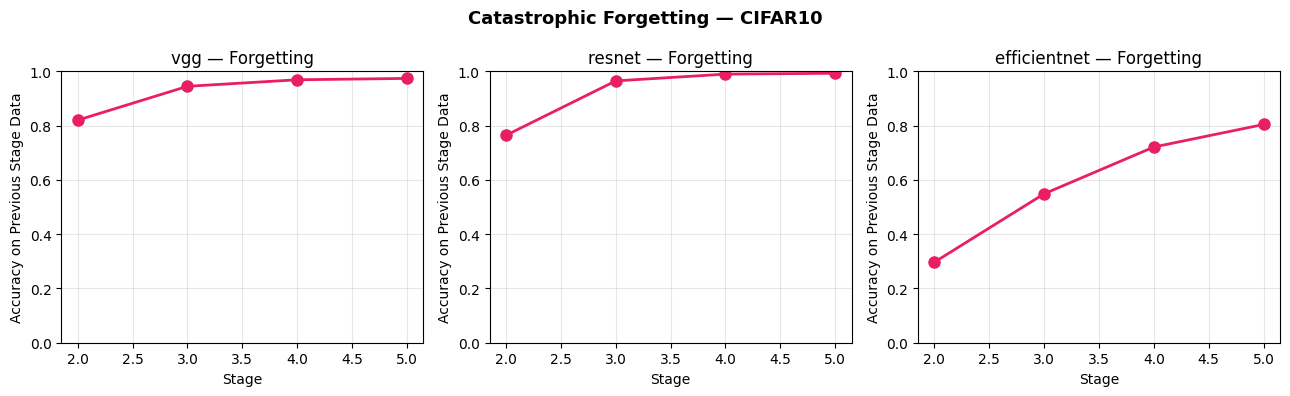

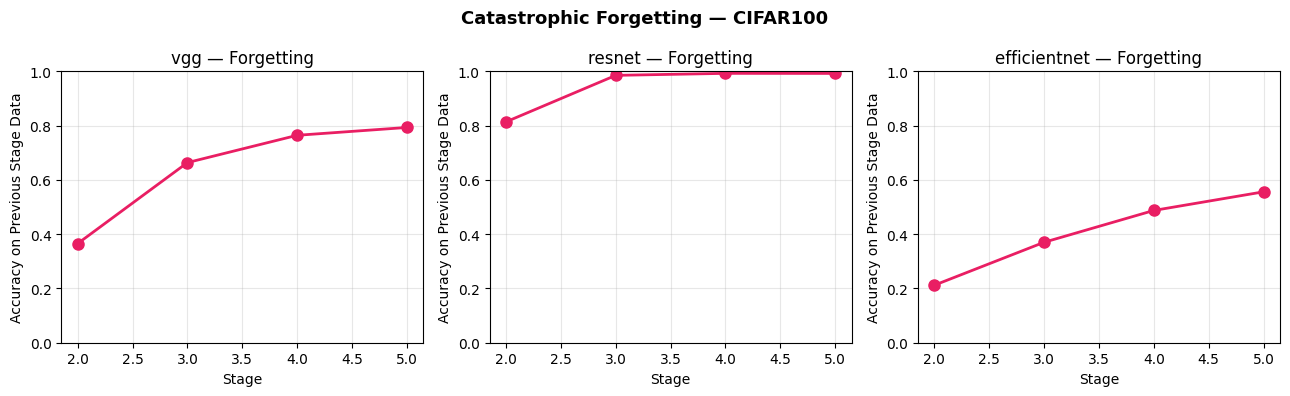

In [ ]:
def plot_forgetting(results, dataset_name='cifar10'):
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))

    for ax, model_name in zip(axes, MODELS):
        key = f'{model_name}_strategy2_progressive_{dataset_name}'
        if key not in results:
            continue

        flog = results[key].get('forgetting_log', [])
        if not flog:
            ax.set_title(f'{model_name} (no data)')
            continue

        stages    = [f['stage'] for f in flog]
        prev_accs = [f['prev_acc'] for f in flog]

        ax.plot(stages, prev_accs, marker='o', color='#E91E63', linewidth=2, markersize=8)
        ax.set_xlabel('Stage')
        ax.set_ylabel('Accuracy on Previous Stage Data')
        ax.set_title(f'{model_name} — Forgetting')
        ax.set_ylim(0, 1)
        ax.grid(alpha=0.3)

    plt.suptitle(f'Catastrophic Forgetting — {dataset_name.upper()}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'forgetting_{dataset_name}.png', dpi=120, bbox_inches='tight')
    plt.show()

plot_forgetting(results, 'cifar10')
plot_forgetting(results, 'cifar100')